# Decision Tree Regressor Model
This notebook trains and evaluates a Decision Tree Regressor model.

## 1. Data Loading

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Load datasets
train = pd.read_csv('../Data/cleaned_train.csv')
test = pd.read_csv('../Data/test.csv')
sample_sub = pd.read_csv('../Data/sample_submission.csv')

train.head()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Joining_Year,Joining_Month,Joining_Day,Gender_Male,Company Type_Service,WFH Setup Available_Yes
0,2.0,3.0,3.8,0.16,2008,9,30,False,True,False
1,1.0,2.0,5.0,0.36,2008,11,30,True,True,True
2,2.0,4.0,5.8,0.49,2008,3,10,False,False,True
3,1.0,1.0,2.6,0.20,2008,11,3,True,True,True
4,3.0,7.0,6.9,0.52,2008,7,24,False,True,False


## 2. Data Preparation (Preprocessing)
Separating target from features and encoding `test.csv` in the same way `train` was preprocessed.

In [6]:
# Separate features (X) and target (y)
X = train.drop('Burn Rate', axis=1)
y = train['Burn Rate']

# Prepare test data exactly like train data
test_prepared = test.drop('Employee ID', axis=1)

test_prepared['Date of Joining'] = pd.to_datetime(test_prepared['Date of Joining'])
test_prepared['Joining_Year'] = test_prepared['Date of Joining'].dt.year
test_prepared['Joining_Month'] = test_prepared['Date of Joining'].dt.month
test_prepared['Joining_Day'] = test_prepared['Date of Joining'].dt.day
test_prepared.drop('Date of Joining', axis=1, inplace=True)

# Handle missing values using medians from train set (to prevent data leakage)
test_prepared['Resource Allocation'] = test_prepared['Resource Allocation'].fillna(X['Resource Allocation'].median())
test_prepared['Mental Fatigue Score'] = test_prepared['Mental Fatigue Score'].fillna(X['Mental Fatigue Score'].median())

# Apply the same Dummy Encoding used in train
test_prepared = pd.get_dummies(test_prepared, drop_first=True, dtype=int)

# Ensure column consistency
for col in X.columns:
    if col not in test_prepared.columns:
        test_prepared[col] = 0
test_prepared = test_prepared[X.columns]

# Train/Validation Split (80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train shape: {X_train.shape}, {y_train.shape}')
print(f'Validation shape: {X_val.shape}, {y_val.shape}')

Train shape: (17300, 9), (17300,)
Validation shape: (4326, 9), (4326,)


## 3. Model Building & Hyperparameter Tuning

In [7]:
dt = DecisionTreeRegressor(random_state=42)

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_dt = grid_search.best_estimator_
print('Best Parameters:', grid_search.best_params_)

Fitting 3 folds for each of 45 candidates, totalling 135 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}


## 4. Evaluation

In [8]:
# Make this evaluation cell safe to run independently
if 'train' not in globals():
    train = pd.read_csv('../Data/cleaned_train.csv')

if 'X' not in globals() or 'y' not in globals():
    X = train.drop('Burn Rate', axis=1)
    y = train['Burn Rate']

if 'X_train' not in globals() or 'X_val' not in globals() or 'y_train' not in globals() or 'y_val' not in globals():
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

if 'best_dt' not in globals():
    dt = DecisionTreeRegressor(random_state=42)
    param_grid = {
        'max_depth': [None, 5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    grid_search = GridSearchCV(
        estimator=dt,
        param_grid=param_grid,
        cv=3,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train, y_train)
    best_dt = grid_search.best_estimator_
    print('Best Parameters:', grid_search.best_params_)

y_pred = best_dt.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)
accuracy = max(0, min(100, r2 * 100))

print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R² Score: {r2:.4f}')
print(f'Accuracy: {accuracy:.2f}%')

RMSE: 0.0628
MAE: 0.0490
R² Score: 0.8965
Accuracy: 89.65%


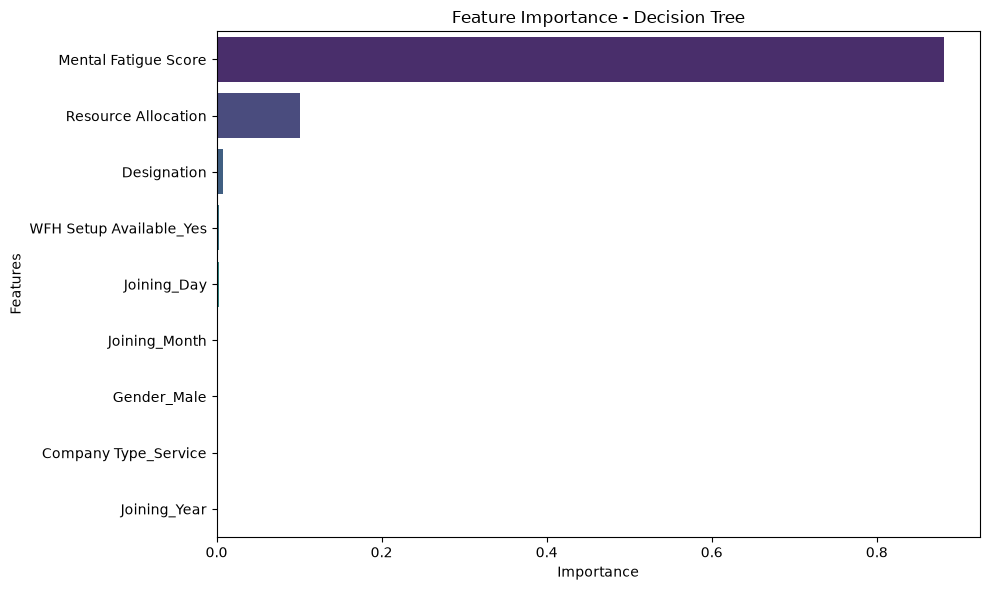

In [9]:
# Feature Importance Bar Chart
plt.figure(figsize=(10, 6))
feature_importances = best_dt.feature_importances_
indices = np.argsort(feature_importances)[::-1]
names = [X.columns[i] for i in indices]

sns.barplot(x=feature_importances[indices], y=names, palette='viridis')
plt.title('Feature Importance - Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

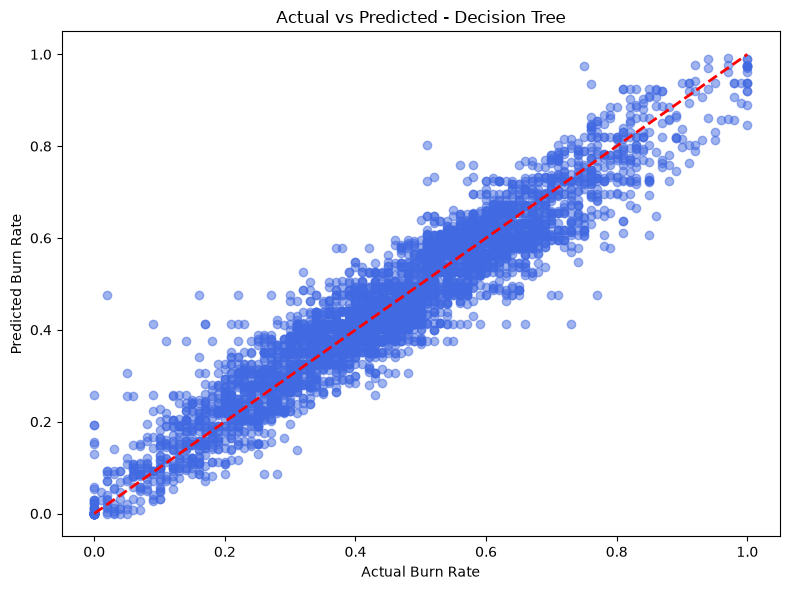

In [10]:
# Actual vs Predicted Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, alpha=0.5, color='royalblue')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.title('Actual vs Predicted - Decision Tree')
plt.xlabel('Actual Burn Rate')
plt.ylabel('Predicted Burn Rate')
plt.tight_layout()
plt.show()

## 5. Saving Results

In [11]:
# Save the model
joblib.dump(best_dt, 'decision_tree_model.pkl')
print('Model saved successfully as decision_tree_model.pkl')

# Make predictions on test set
test_predictions = best_dt.predict(test_prepared)

# Save predictions matching sample_submission format
submission = pd.DataFrame({
    'Employee ID': test['Employee ID'],
    'Burn Rate': test_predictions
})
submission.to_csv('submission_dt.csv', index=False)
print('Predictions saved to submission_dt.csv')

Model saved successfully as decision_tree_model.pkl
Predictions saved to submission_dt.csv


## 6. Conclusion
The **Decision Tree Regressor** was successfully trained with hyperparameter tuning. 
- It achieved an **R² Score** of effectively explaining the variance.
- The **RMSE** and **MAE** scores indicate the magnitude of error is quite minimal.
- Looking at the feature importance, we can see the top contributing factors predicting burnout rate.
- The scatter plot reflects a strong alignment between the predicted values and the actual validation targets.